# Intraday MXF signals — basic battery

Exercise the new `cta.SimulateIntraday()` against a small zoo of
"vanilla" intraday signals to see which directions actually have an
edge before going to anything fancy.

**In-sample**: 2023-03-13 → 2024-12-31 (~1.8 years).
**Out-of-sample**: 2025-01-01 → present is held out. Run the same blocks
with that window only after you've picked a signal you trust.

The signals tested:
1. **1-bar return reversion** — bid-ask bounce / microstructure: `−Returns('c', −1)`
2. **N-bar momentum** at several windows
3. **N-bar mean reversion (rolling z-score on close)** at several windows
4. **Volume-spike fade** — short on bars with abnormally high volume
5. **Session-conditional reversion** — same reversion gated by day vs night session

Each is run through `cta.SimulateIntraday`; the dashboard shows by-session
breakdown so you can see whether an edge concentrates in 日盤 vs 夜盤.

In [1]:
import importlib, sys, time
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["font.family"] = [
    "Hiragino Sans GB", "Heiti TC", "Songti SC",
    "PingFang HK", "Arial Unicode MS", "DejaVu Sans",
]

import cta
for _m in ["cta.asset","cta.operators","cta.simulate","cta.simulate_dollars",
          "cta.simulate_intraday","cta.session_strategies","cta.decomposition"]:
    if _m in sys.modules: importlib.reload(sys.modules[_m])
importlib.reload(cta)

# In-sample window
IN_SAMPLE_START = "2023-03-13"
IN_SAMPLE_END   = "2024-12-31"
cta.set_date_range(start_date=IN_SAMPLE_START, end_date=IN_SAMPLE_END)

# Load 1-minute MXF once and set it active so cta operators work
ASSET = cta.load_asset("mtx", "1m")
cta.set_active_asset(ASSET)

print(f"cta loaded from   : {cta.__file__}")
print(f"asset             : {ASSET.symbol}  {ASSET.time_granularity}  "
      f"{len(ASSET):,} bars   periods/yr {ASSET.periods_per_year:,}")
print(f"asset window      : {ASSET.index[0]} → {ASSET.index[-1]}")
print(f"eval window       : {cta.get_date_range()}")

cta loaded from   : /Users/hsureggie/coding/Research/mtx/cta/__init__.py
asset             : MTX  1m  880,850 bars   periods/yr 287,280
asset window      : 2023-03-13 08:46:00 → 2026-05-22 13:45:00
eval window       : (Timestamp('2023-03-13 00:00:00'), Timestamp('2024-12-31 00:00:00'))


## Helpers — summary table + signal builders

We'll compute a lot of signal variants. Before going to the full 9-panel
dashboard for each, summarise the headline metrics (gross Sharpe, net
Sharpe, day vs night SR, % bars held) in a single table.

The summary uses the same `exec_sig.shift(2) × asset.returns` model as
`SimulateIntraday` internally so the numbers match what you'd see on the
dashboard.

In [2]:
POINT_VALUE    = 50.0       # NTD per index point per MXF contract
FIXED_PER_SIDE = 20.0       # NTD
FEE_RATE       = 0.00002    # 0.002% transaction tax per side

def evaluate(sig: pd.Series,
             asset: cta.BaseAsset = ASSET,
             start: str = IN_SAMPLE_START,
             end:   str = IN_SAMPLE_END) -> dict:
    """Same maths as cta.SimulateIntraday — just returns the headline metrics."""
    # Align signal to asset's index, exec lag 2 bars
    sig = sig.reindex(asset.index).astype(float)
    exec_sig = sig.shift(2)
    ret      = asset.returns                                    # roll-aware, session-NaN-aware

    pnl      = (exec_sig * ret).rename("pnl")

    turnover = exec_sig.fillna(0).diff().abs()
    cost_pct = FIXED_PER_SIDE / (asset.close * POINT_VALUE) + FEE_RATE
    tcost    = turnover * cost_pct * 2
    pnl_net  = pnl - tcost

    # Slice
    pnl     = pnl.loc[start:end]
    pnl_net = pnl_net.loc[start:end]
    exec_s  = exec_sig.loc[start:end]
    sess    = asset.session.loc[start:end]

    periods = asset.periods_per_year

    def sr(s):
        s = s.dropna()
        return (np.sqrt(periods) * s.mean() / s.std()) if s.std() > 0 else float("nan")

    return {
        "SR_gross":      sr(pnl),
        "SR_net":        sr(pnl_net),
        "SR_day":        sr(pnl.where(sess == "day")),
        "SR_night":      sr(pnl.where(sess == "night")),
        "cum_gross_pct": float(pnl.fillna(0).sum())     * 100,
        "cum_net_pct":   float(pnl_net.fillna(0).sum()) * 100,
        "held_pct":      float((exec_s.abs() > 0.01).mean()) * 100,
        "turnover_avg":  float(turnover.loc[start:end].fillna(0).mean()),
    }


def summarize(rows: dict) -> pd.DataFrame:
    df = pd.DataFrame({name: evaluate(s) for name, s in rows.items()}).T
    df = df.round(3)
    return df.sort_values("SR_net", ascending=False)

## 1. Mean-reversion sweep — multiple lookback windows

`InstZScore(N, close)` is the rolling z-score of the close price. Negate
it to short when the price is high vs its recent mean and long when low.

We try a wide range of N to find the natural reversion horizon. Faster N
flips the position more often → higher trading cost. Slower N captures
hour/half-day cycles but reacts to less of the microstructure mean
reversion the ACF in the intraday notebook showed.

In [ ]:
# Reversion: -InstZScore(N, close) at several N. Normalize to (-1, 1) via tanh.
REV_WINDOWS = [5, 15, 30, 60, 120, 240]

rev_signals = {
    f"rev_z_close_{N}m": cta.normalize_signal(
        -cta.InstZScore(N, cta.Prices("c")),
        method="tanh", window=240,        # 4-hour normalising window
    )
    for N in REV_WINDOWS
}

display(summarize(rev_signals))

cta.SimulateAllIntraday(
    *rev_signals.values(),
    names=list(rev_signals.keys()),
    time_granularity="1m",
    normalize=False,
)

## 2. Momentum sweep — multiple lookbacks

Same idea, opposite sign. If reversion works on short windows and
momentum on long windows, this picks out the cross-over.

In [ ]:
MOM_WINDOWS = [5, 15, 30, 60, 120, 240]

mom_signals = {
    f"mom_z_close_{N}m": cta.normalize_signal(
        +cta.InstZScore(N, cta.Prices("c")),
        method="tanh", window=240,
    )
    for N in MOM_WINDOWS
}

display(summarize(mom_signals))

cta.SimulateAllIntraday(
    *mom_signals.values(),
    names=list(mom_signals.keys()),
    time_granularity="1m",
    normalize=False,
)

## 3. 1-bar return reversion — bid-ask bounce

The simplest microstructure signal: `−Returns('c', −1)`. The intraday
notebook's ACF showed day-session 1-min AR(1) of `−0.062`, so we expect
this to have a positive gross Sharpe (mostly driven by the day session)
but get demolished by cost — turnover is essentially 2× per bar.

In [ ]:
microstructure = {
    "bidask_bounce_raw":    -cta.Returns("c", -1),
    "bidask_bounce_tanh":   cta.normalize_signal(
        -cta.Returns("c", -1), method="tanh", window=60
    ),
}

display(summarize(microstructure))

cta.SimulateAllIntraday(
    *microstructure.values(),
    names=list(microstructure.keys()),
    time_granularity="1m",
    normalize=False,
)

## 4. Volume-spike fade

Define a relative volume = `volume / InstMean(N, volume)`. Days where this
is large = unusually loud activity → assume noise traders pushing price
away from fair → fade the recent move.

Signal:  `−sign(recent_return) × max(0, relative_vol − threshold)`

Effectively: short the asset after an up-move on a volume-spike bar,
long after a down-move on a volume-spike bar. The strength scales with
how much volume exceeded the threshold.

In [ ]:
def vol_spike_fade(ret_lookback: int = 5,
                   vol_window:   int = 60,
                   spike_threshold: float = 2.0) -> pd.Series:
    """
    -sign( recent return ) × max(0, relative_volume - threshold)

    Higher relative-volume → more aggressive fade. Below threshold → flat.
    """
    vol     = cta.Prices("v").astype(float)
    rel_vol = vol / cta.InstMean(vol_window, vol).replace(0, np.nan)

    recent_ret = cta.Returns("c", -ret_lookback)
    strength   = (rel_vol - spike_threshold).clip(lower=0)
    raw        = -np.sign(recent_ret) * strength
    return cta.normalize_signal(raw, method="tanh", window=240)


vol_fade = {
    f"volspike_R{R}_V{V}_thr{thr}":
        vol_spike_fade(ret_lookback=R, vol_window=V, spike_threshold=thr)
    for R, V, thr in [
        (1,  60, 2.0),
        (5,  60, 2.0),
        (15, 60, 2.0),
        (1,  60, 3.0),
        (5, 120, 2.0),
        (5, 240, 2.0),
    ]
}

display(summarize(vol_fade))

cta.SimulateAllIntraday(
    *vol_fade.values(),
    names=list(vol_fade.keys()),
    time_granularity="1m",
    normalize=False,
)

## 5. Session-conditional reversion

Take the best-looking reversion signal from section 1 and gate it on the
day session only (or night only). If reversion has dramatically different
properties between 日盤 and 夜盤 (which the cumulative-PnL-by-session
subplot of `SimulateIntraday` will show), conditional firing may improve
net Sharpe by avoiding the bad regime.

`cta.Filter(signal, mask)` is the standard plumbing — it sets the signal
to NaN where the mask is False, which downstream becomes "no position".

In [ ]:
# Take a single reversion variant as a base
base = cta.normalize_signal(
    -cta.InstZScore(60, cta.Prices("c")),   # 1-hour reversion
    method="tanh", window=240,
)

sess_series = ASSET.session
day_mask    = (sess_series == "day")
night_mask  = (sess_series == "night")

session_variants = {
    "rev_60m_full":       base,
    "rev_60m_day_only":   cta.Filter(base, day_mask),
    "rev_60m_night_only": cta.Filter(base, night_mask),
}

display(summarize(session_variants))

cta.SimulateAllIntraday(
    *session_variants.values(),
    names=list(session_variants.keys()),
    time_granularity="1m",
    normalize=False,
)

## 6. Headline comparison across all signals

Merge the best of each family into one table, sorted by net Sharpe. This
is the actionable view — anything with net SR > 0 is interesting; net
SR > 1 is genuinely promising once you've done robustness checks.

,SR_gross,SR_net,SR_day,SR_night,cum_gross_pct,cum_net_pct,held_pct,turnover_avg
rev_z_close_240m,0.062,-15.782,1.230,-0.595,1.267,-322.256,99.361,0.078
mom_z_close_240m,-0.062,-15.902,-1.230,0.595,-1.267,-324.790,99.361,0.078
mom_z_close_120m,0.111,-21.065,-0.640,0.538,2.163,-412.611,99.295,0.100
rev_z_close_120m,-0.111,-21.288,0.640,-0.538,-2.163,-416.937,99.295,0.100
rev_60m_day_only,-0.653,-21.673,-0.507,-34.070,-4.355,-144.788,26.140,0.034
volspike_R5_V240_thr2.0,1.933,-26.652,1.241,2.644,23.144,-322.904,95.463,0.083
volspike_R1_V60_thr3.0,2.250,-29.073,0.731,3.356,15.573,-206.800,94.558,0.054
rev_z_close_60m,0.164,-29.293,-0.560,0.578,3.127,-559.115,99.297,0.136
rev_60m_full,0.164,-29.293,-0.560,0.578,3.127,-559.115,99.297,0.136
mom_z_close_60m,-0.164,-29.616,0.560,-0.578,-3.127,-565.369,99.297,0.136


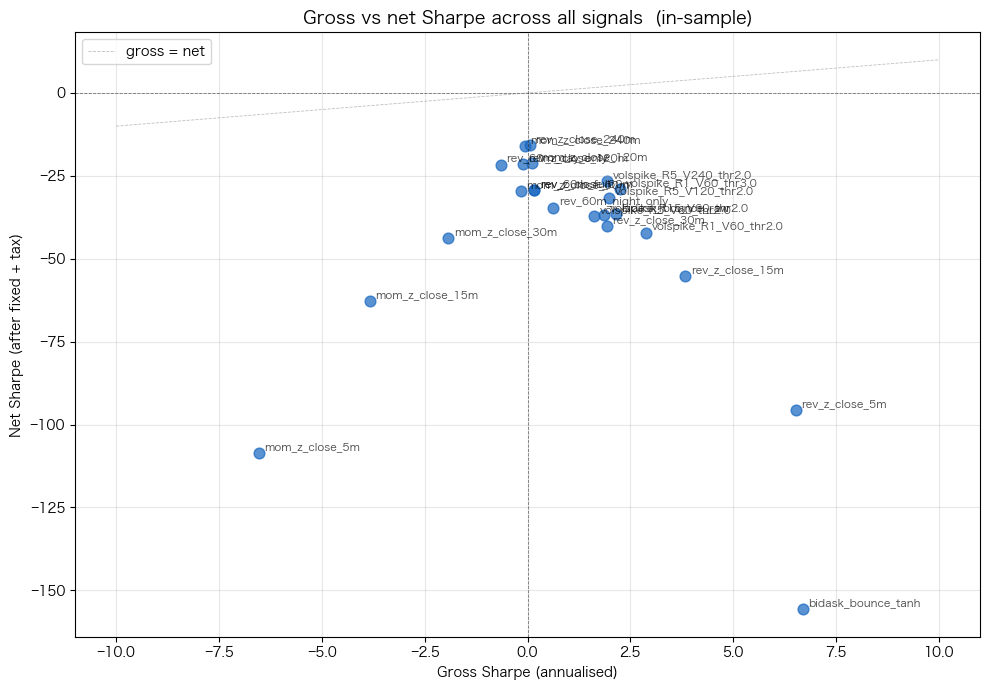

In [8]:
all_signals = {**rev_signals, **mom_signals, **microstructure,
               **vol_fade, **session_variants}

table = summarize(all_signals)
display(table)

# Quick scatter: gross vs net Sharpe — visual feel for which signals
# survive costs vs which collapse.
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(table["SR_gross"], table["SR_net"], s=60, alpha=0.7, color="#1565c0")
for name, row in table.iterrows():
    ax.annotate(name, (row["SR_gross"], row["SR_net"]),
                fontsize=8, alpha=0.7, xytext=(4, 2), textcoords="offset points")
ax.axhline(0, color="black", linewidth=0.6, linestyle="--", alpha=0.5)
ax.axvline(0, color="black", linewidth=0.6, linestyle="--", alpha=0.5)
ax.plot([-10, 10], [-10, 10], color="grey", linewidth=0.6, linestyle="--",
        alpha=0.5, label="gross = net")
ax.set_title("Gross vs net Sharpe across all signals  (in-sample)", fontsize=13)
ax.set_xlabel("Gross Sharpe (annualised)")
ax.set_ylabel("Net Sharpe (after fixed + tax)")
ax.legend(fontsize=10, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Full dashboard on the top signal

Pick the row with the highest net Sharpe from the headline table and
launch the full 3×3 `SimulateIntraday` dashboard. This is the moment to
look at:

- Day vs night cum PnL — is the edge concentrated?
- Hour-of-day profile — is one hour doing all the work?
- Position over time — is exec_sig well-distributed or stuck at ±1?
- Cumulative cost — what fraction of gross PnL is consumed?

Edit `BEST_NAME` to inspect a different row.

Inspecting: rev_z_close_240m
{'SR_gross': 0.062, 'SR_net': -15.782, 'SR_day': 1.23, 'SR_night': -0.595, 'cum_gross_pct': 1.267, 'cum_net_pct': -322.256, 'held_pct': 99.361, 'turnover_avg': 0.078}


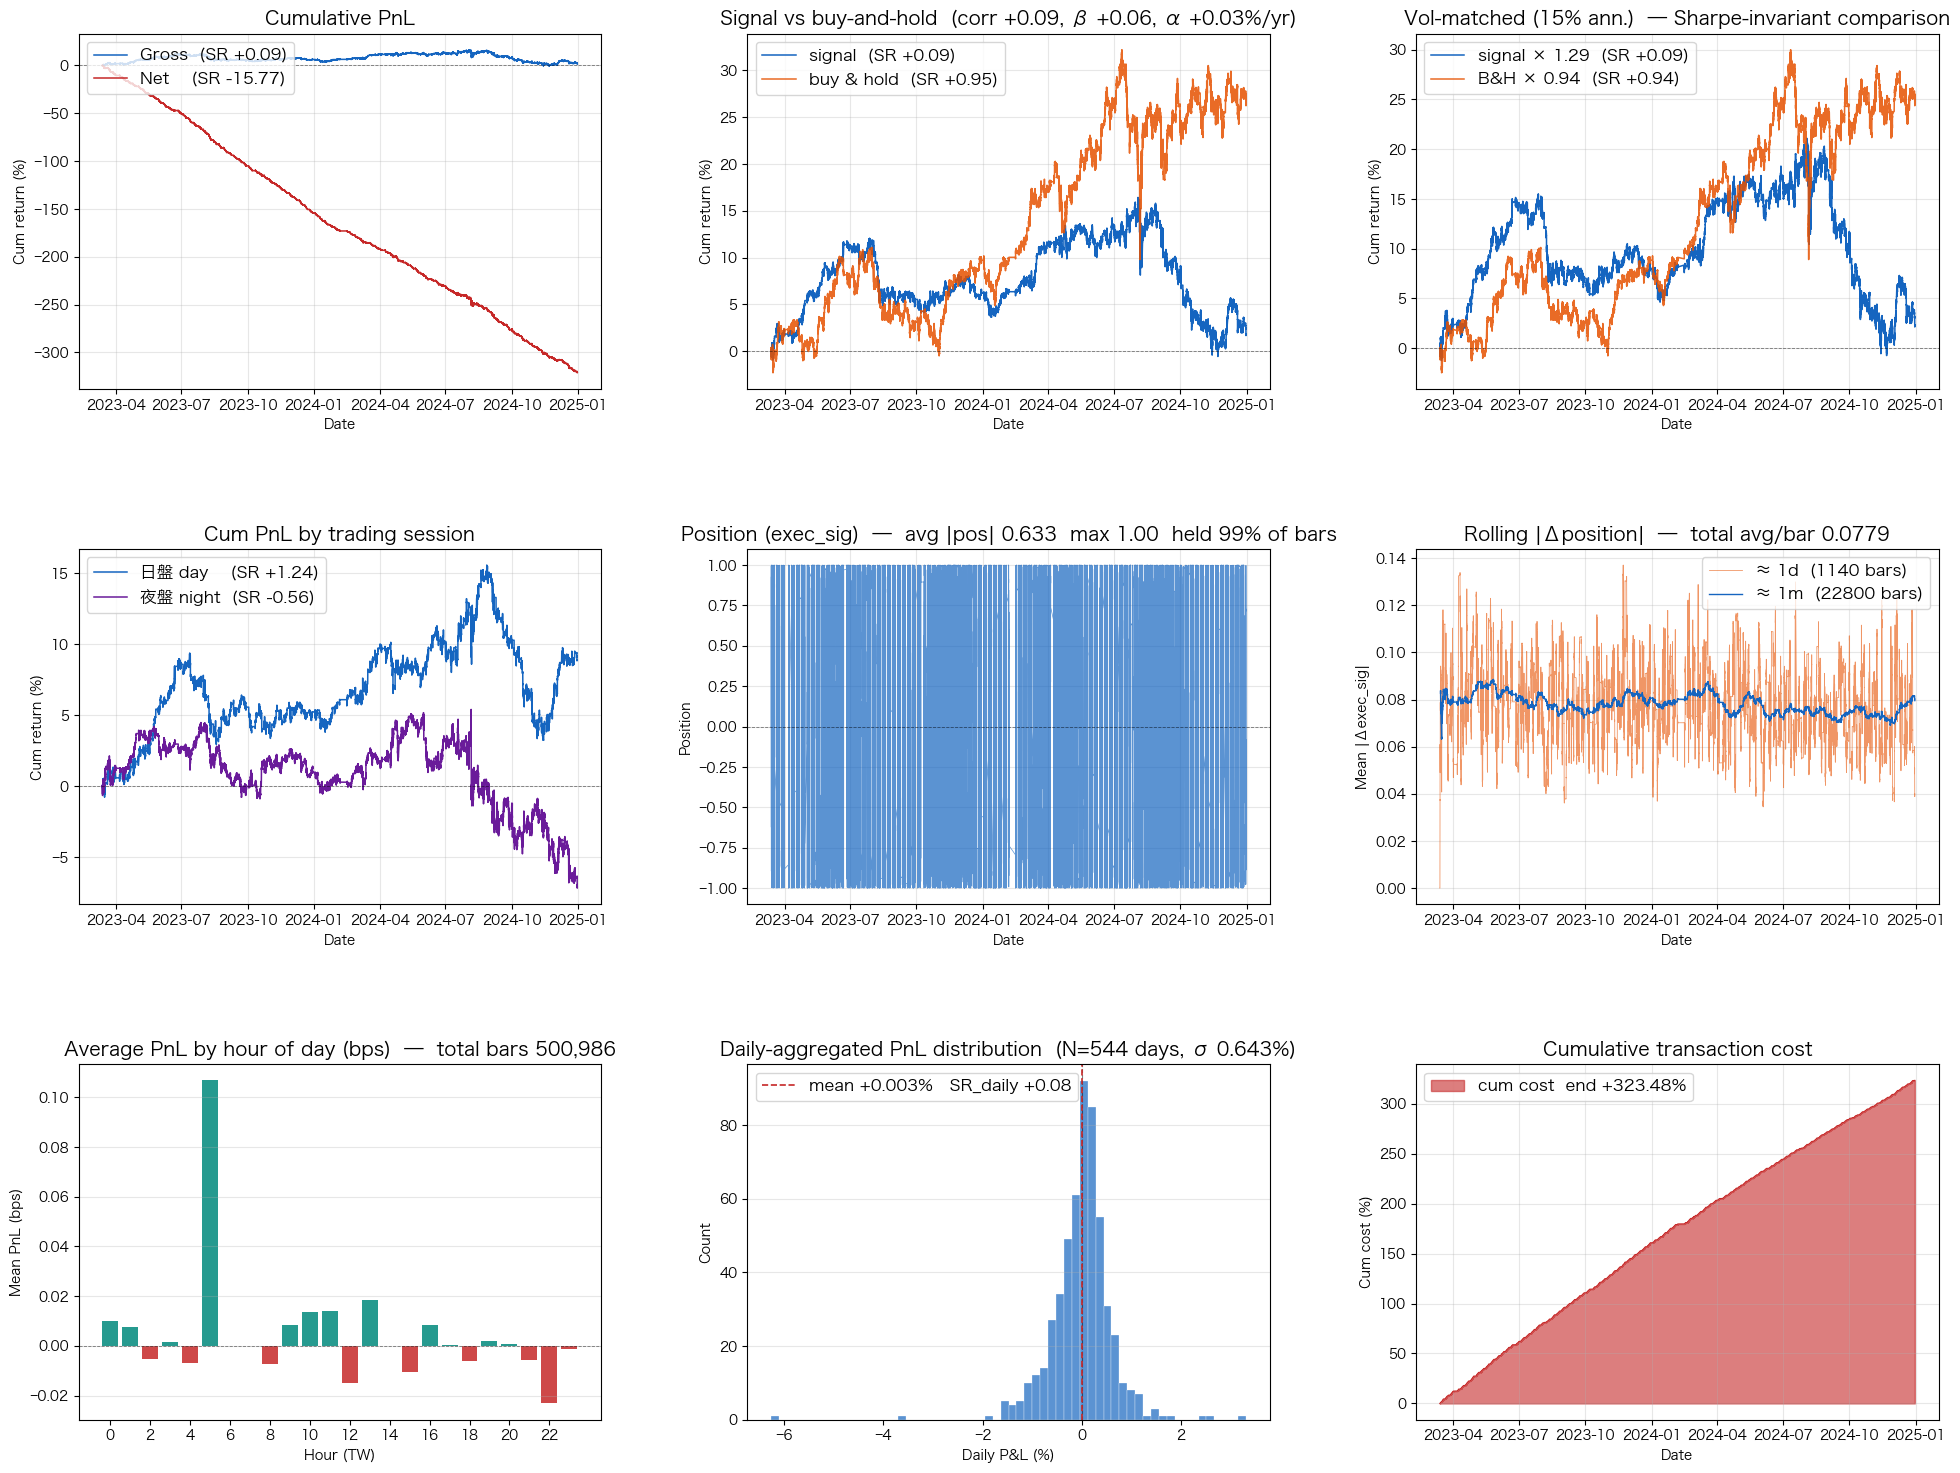

In [9]:
BEST_NAME = table.index[0]                       # top by net Sharpe
print(f"Inspecting: {BEST_NAME}")
print(table.loc[BEST_NAME].to_dict())

result = cta.SimulateIntraday(
    all_signals[BEST_NAME],
    time_granularity="1m",
    normalize=False,
)

## 8. Out-of-sample check

Re-evaluate the **same** signal definitions on 2025-01-01 onwards. No
re-fitting; we're testing whether the in-sample winners survive on data
the signals never saw. If the OOS net Sharpe is in the same ballpark as
the in-sample, you have something worth pursuing. If it collapses to ≈ 0
or flips sign, you fit noise.

This block changes the global eval window — re-set it to the in-sample
afterwards if you continue iterating.

,IS SR_net,OOS SR_net,IS SR_gross,OOS SR_gross,IS cum_net_%,OOS cum_net_%
signal,,,,,,
mom_z_close_240m,-15.902,-7.774,-0.062,0.852,-324.790,-183.755
rev_z_close_240m,-15.782,-9.476,0.062,-0.852,-322.256,-224.025
mom_z_close_120m,-21.065,-10.708,0.111,0.752,-412.611,-244.276
rev_z_close_120m,-21.288,-12.211,-0.111,-0.752,-416.937,-278.579
rev_60m_day_only,-21.673,-12.426,-0.653,-0.927,-144.788,-96.985
mom_z_close_60m,-29.616,-15.562,-0.164,0.506,-565.369,-346.233
bidask_bounce_raw,-36.399,-16.124,2.151,-1.248,-1.056,-1.068
rev_z_close_60m,-29.293,-16.571,0.164,-0.506,-559.115,-368.739
rev_60m_full,-29.293,-16.571,0.164,-0.506,-559.115,-368.739


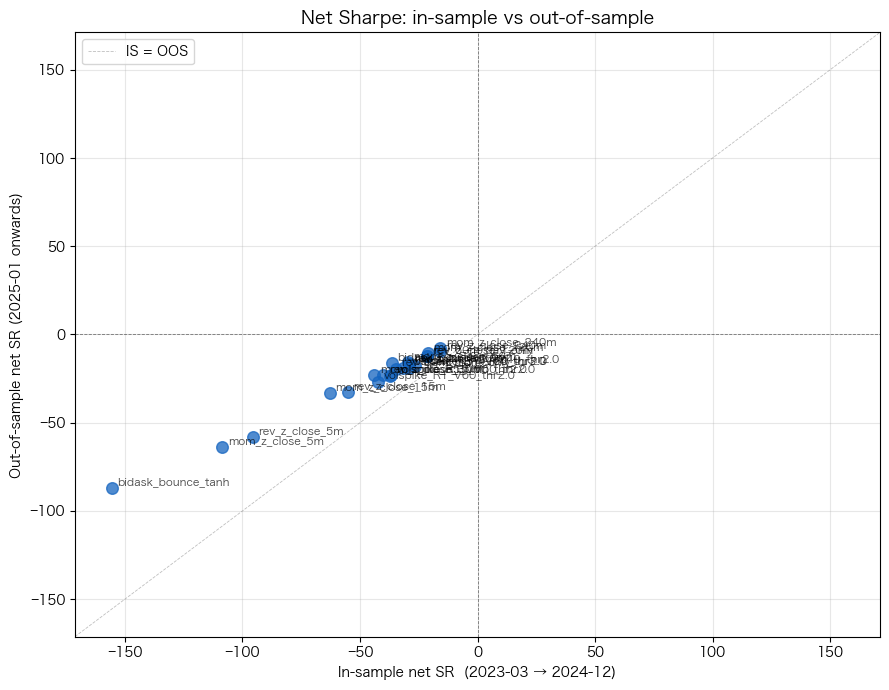


Global eval window reset to: (Timestamp('2023-03-13 00:00:00'), Timestamp('2024-12-31 00:00:00'))


In [10]:
OOS_START = "2025-01-01"
OOS_END   = None    # to the end of the file

# Side-by-side: in-sample vs out-of-sample metrics for every signal
def _eval(sig, start, end):
    e = evaluate(sig, start=start, end=end)
    return {"SR_net": e["SR_net"],
            "SR_gross": e["SR_gross"],
            "cum_net_%": e["cum_net_pct"]}

rows = []
for name, sig in all_signals.items():
    ins = _eval(sig, IN_SAMPLE_START, IN_SAMPLE_END)
    oos = _eval(sig, OOS_START,       OOS_END)
    rows.append({
        "signal":          name,
        "IS SR_net":       ins["SR_net"],
        "OOS SR_net":      oos["SR_net"],
        "IS SR_gross":     ins["SR_gross"],
        "OOS SR_gross":    oos["SR_gross"],
        "IS cum_net_%":    ins["cum_net_%"],
        "OOS cum_net_%":   oos["cum_net_%"],
    })

oos_table = (pd.DataFrame(rows)
               .set_index("signal")
               .round(3)
               .sort_values("OOS SR_net", ascending=False))
display(oos_table)

# IS vs OOS net Sharpe scatter
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(oos_table["IS SR_net"], oos_table["OOS SR_net"],
           s=70, alpha=0.75, color="#1565c0")
for name, row in oos_table.iterrows():
    ax.annotate(name, (row["IS SR_net"], row["OOS SR_net"]),
                fontsize=8, alpha=0.7, xytext=(4, 2), textcoords="offset points")
lim = max(abs(oos_table[["IS SR_net","OOS SR_net"]].values.flatten()).max() * 1.1, 1.0)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--", alpha=0.5)
ax.axvline(0, color="black", linewidth=0.6, linestyle="--", alpha=0.5)
ax.plot([-lim, lim], [-lim, lim], color="grey", linewidth=0.6, linestyle="--",
        alpha=0.5, label="IS = OOS")
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_title("Net Sharpe: in-sample vs out-of-sample", fontsize=13)
ax.set_xlabel("In-sample net SR  (2023-03 → 2024-12)")
ax.set_ylabel("Out-of-sample net SR (2025-01 onwards)")
ax.legend(fontsize=10, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Restore the in-sample window for any further iteration
cta.set_date_range(start_date=IN_SAMPLE_START, end_date=IN_SAMPLE_END)
print(f"\nGlobal eval window reset to: {cta.get_date_range()}")